In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from midiutil import MIDIFile
from audiolazy_functions import str2midi, midi2str  # using premade functions from a sonification tutorial to convert notes to MIDI 
from IPython.display import Audio
from music21 import note, stream

In [3]:
df = pd.read_csv("temp_data.csv", skiprows=7, names=['years', 1,2,3,4,5,6,7,8,9,10,11,12])

In [4]:
df.head()

,years,1,2,3,4,5,6,7,8,9,10,11,12
0,1906,3.29,2.28,3.79,7.67,12.41,14.17,16.79,17.00,13.35,11.65,7.50,-0.28
1,1907,1.48,0.41,4.60,7.43,12.49,13.52,13.90,15.55,13.79,11.24,5.58,3.09
2,1908,-1.25,3.29,3.44,5.89,12.98,16.22,16.65,15.08,13.43,9.78,4.23,0.97
3,1909,0.54,0.30,2.97,8.55,11.30,12.94,14.58,16.31,13.02,10.95,3.89,3.01
4,1910,3.26,4.03,5.26,7.84,12.43,16.00,15.15,16.22,13.35,10.38,3.31,5.34


Text(0.5, 1.0, 'Temperature across the years for the 7th month')

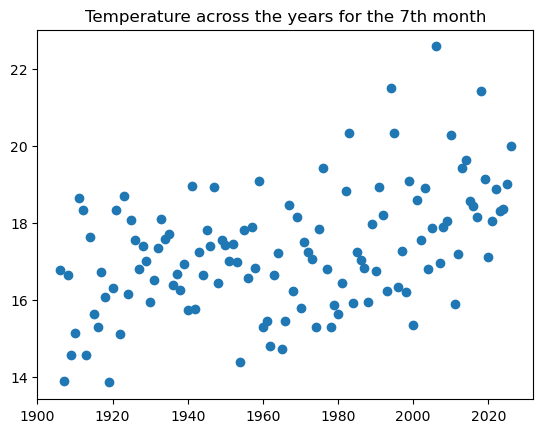

In [5]:
month = 7

plt.scatter(df['years'].values, df[month].values)

plt.title(f'Temperature across the years for the {month}th month')


Text(0, 0.5, 'temperature (celcius)')

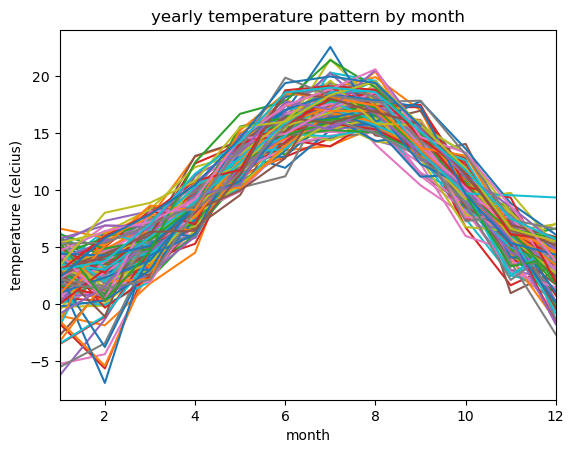

In [6]:
plt.plot(df.set_index('years').T)
plt.title('yearly temperature pattern by month')
plt.xlim((1,12))
plt.xlabel('month')
plt.ylabel('temperature (celcius)')

Text(0.5, 1.0, 'Temperature changes between 1906-2026')

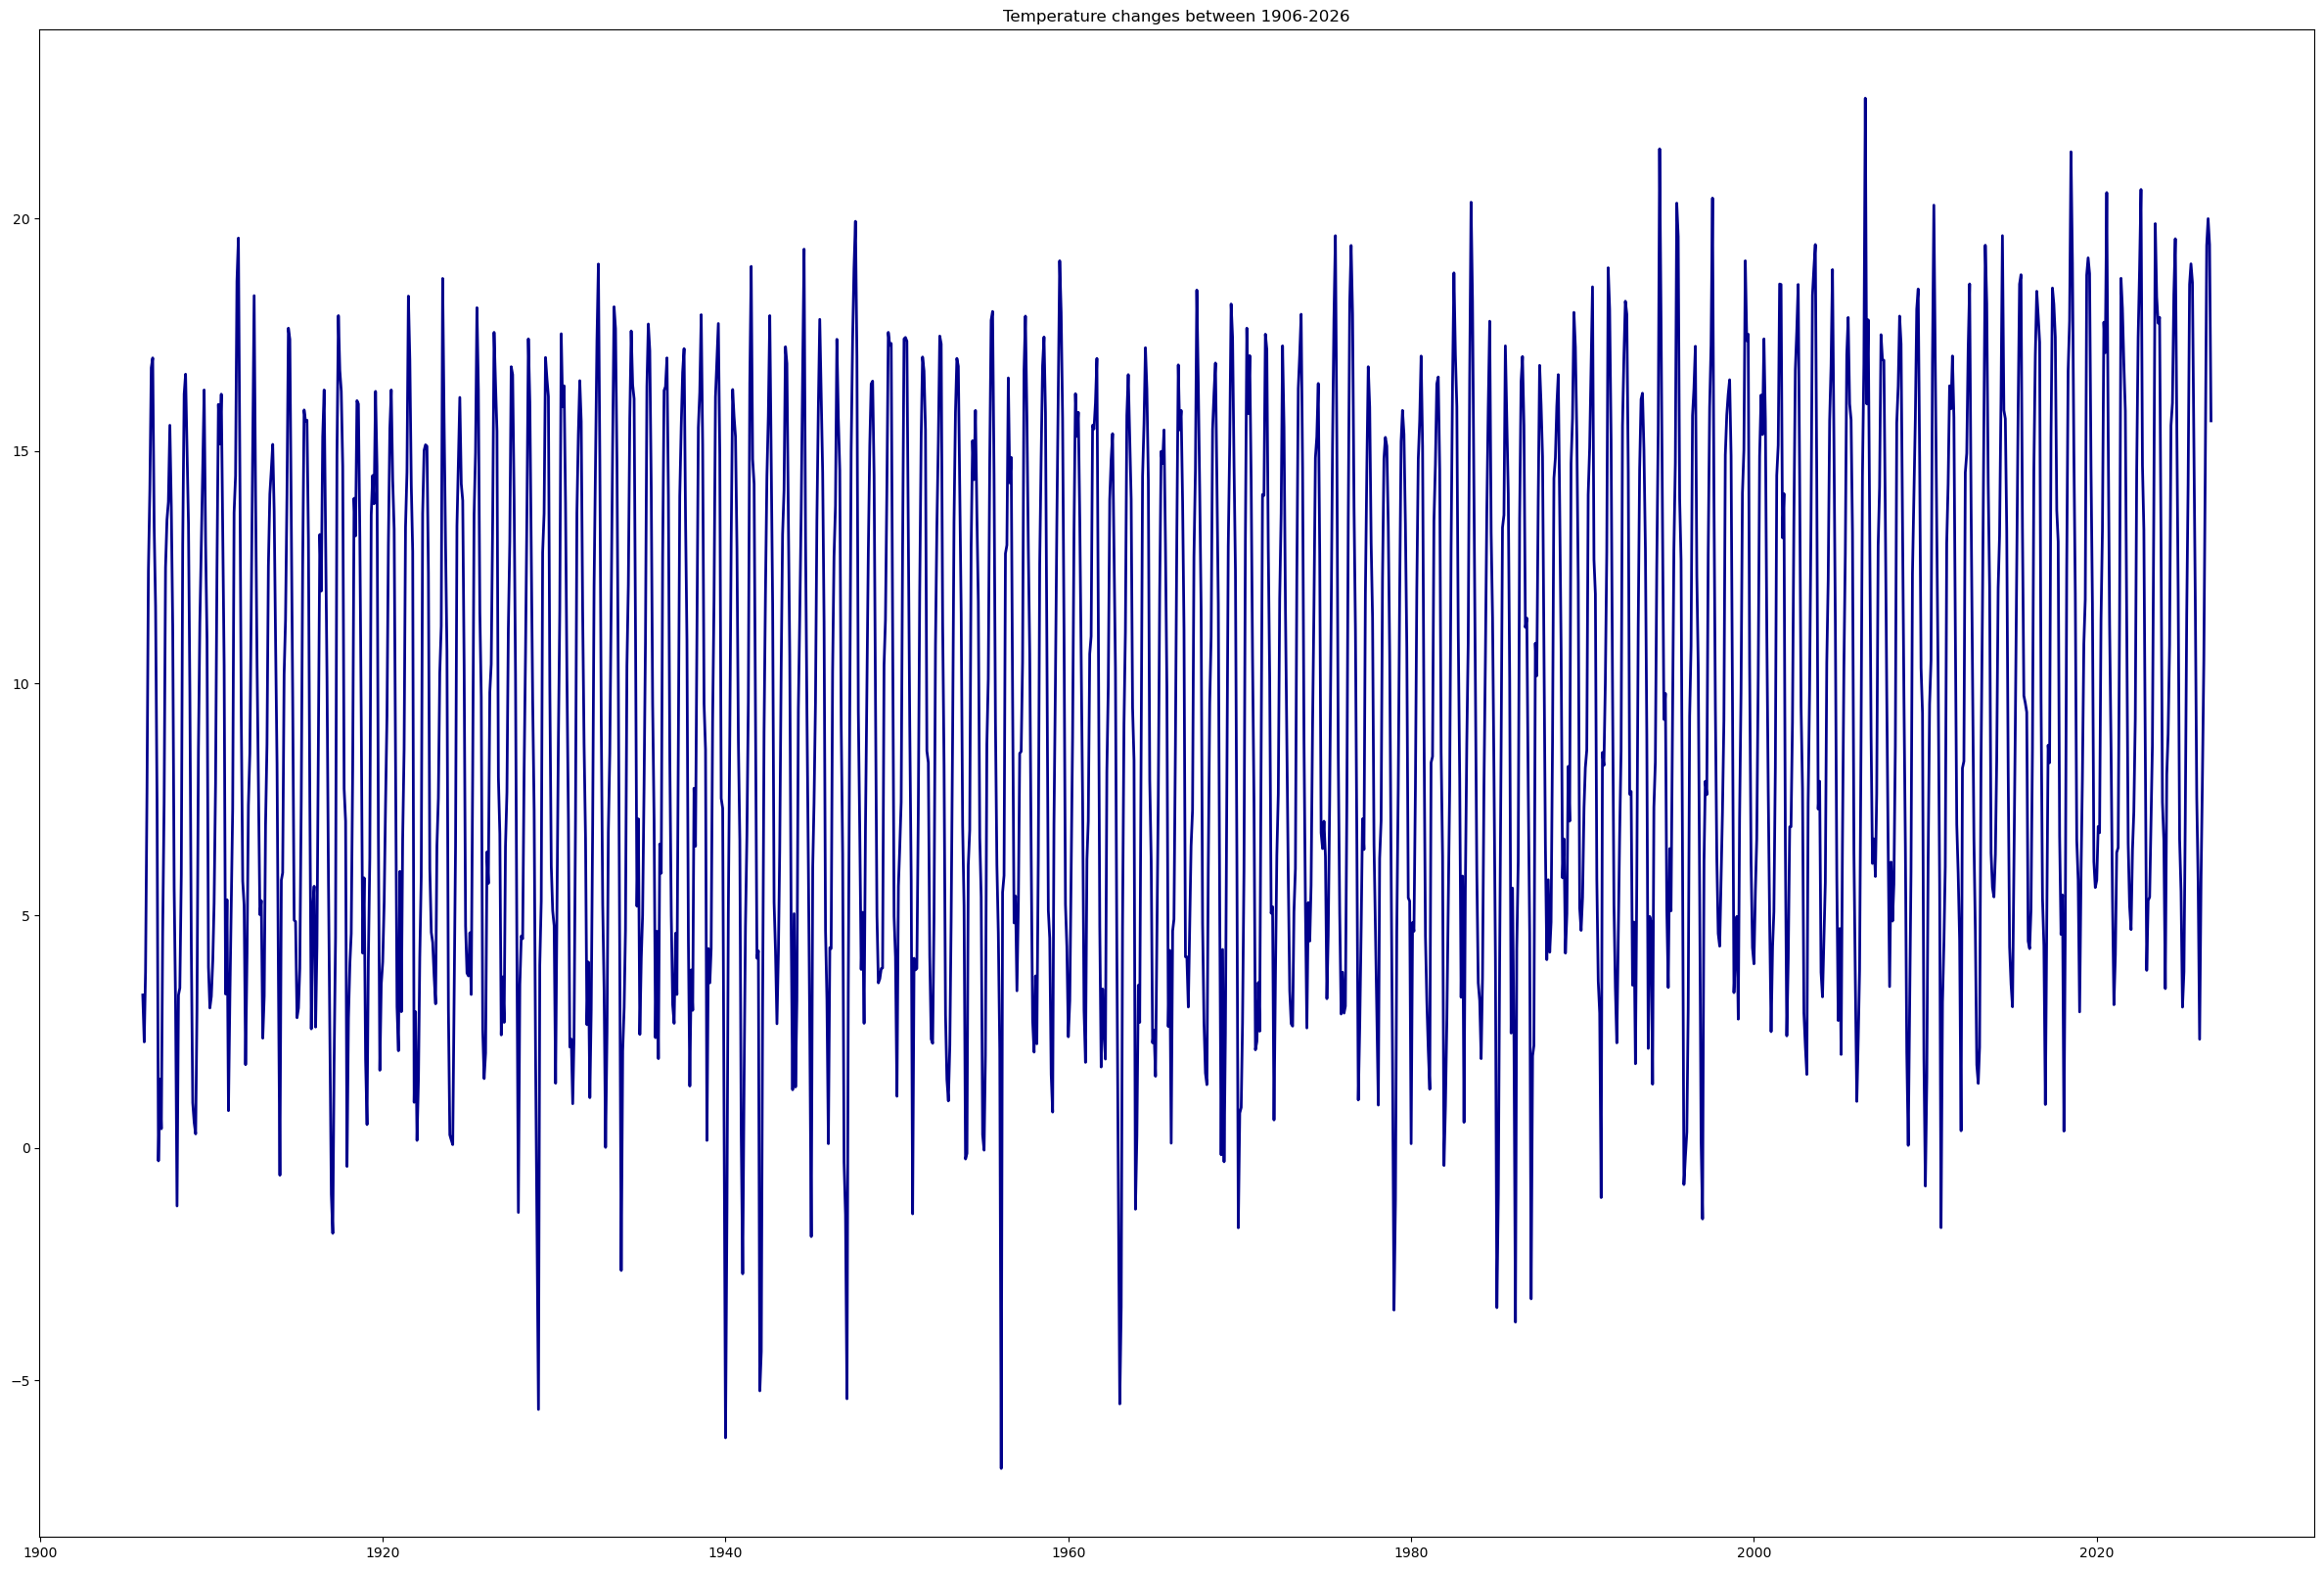

In [7]:
df_long = df.melt(id_vars="years", var_name="month", value_name="temperature")
df_long['date'] = pd.to_datetime(df_long[['years', 'month']].assign(day=1))
df_long = df_long.sort_values('date')
df_long.head(15)

mini, maxi = (min(df_long['years']), max(df_long['years']))



plt.figure(figsize=(30,20))
plt.plot(df_long['date'], df_long['temperature'], color='darkblue', linewidth=2)
plt.title(f'Temperature changes between {mini}-{maxi}')


## Mappings 

https://medium.com/@astromattrusso/sonification-101-how-to-convert-data-into-music-with-python-71a6dd67751c 

C-lydian scale 

each month is the base melody and on top of that a "bonnngg" sound based on the mean temperature of the year 

In [8]:
# function taken from sonification tutorial 
def map_value(value, min_value, max_value, min_result, max_result):
    '''maps value (or array of values) from one range to another'''
 
    result = min_result + (value - min_value)/(max_value - min_value)*(max_result - min_result)
    return result

In [9]:
map_value(5, 1, 10, 10, 20)

14.444444444444445

In [10]:
note_names = ['C1', 'D1', 'E1', 'F#1', 'G1', 'A1', 'B1', 'C2', 'D2', 'E2', 'F#2', 'G2', 'A2', 'B2','C3', 'D3', 'E3', 'F#3', 'G3', 'A3', 'B3', 'C4', 'D4', 'E4', 'F#4', 'G4', 'A4', 'B4', 'C5', 'D5']
midi_notes = (str2midi(n) for n in note_names)
midi_notes = list(midi_notes)
n_notes = len(note_names)

t_notes = [note.Note(n) for n in note_names]
stream_ = stream.Stream(t_notes)
stream_.show('midi', autoplay=True)



In [11]:
n_notes

30

In [12]:
len(midi_notes)

30

1440 datapoints mapped to a certain number of notes 

let's look at our temperature range to see how the mapping would look 

In [13]:
mins = []
maxs = []

for year in range(1906, 2027):
    temps = df[df['years']==year].values
    # print((temps[0][1:]))     # temp is (1,13) dimensional array, so we 
    mins.append(min(temps[0][1:]))
    maxs.append(max(temps[0][1:]))

print(len(mins), len(maxs))

print(min(mins), max(maxs))

temp_range = max(maxs) - min(mins)
print(temp_range)

121 121
-6.9 22.59
29.490000000000002


the range of temepratures in our data is 29, from -6.9 to 22.59. if we wanna map each value between -6.9 and 22.59 to a note maybe it makes sense to round all of the temperatures to the nearest whole number so that we don't need to account for all of the decimal numbers in the data.

maybe it then also makes sense to extend our note list to also have 29 notes. so that the mapping is 1-to-1 between the notes and the temperatures. then the increase in temperature will also match the increase in the octaves? 

### creating a new dataframe for the processed temperature data: rounding the temperature values 

In [14]:
processed_df = (df.round())
long_proc_df = processed_df.melt(id_vars='years', var_name="month", value_name='temperature')
long_proc_df['date'] = pd.to_datetime(long_proc_df[['years', 'month']].assign(day=1))
long_proc_df = long_proc_df.sort_values('date')
long_proc_df

,years,month,temperature,date
0,1906,1,3.0,1906-01-01
121,1906,2,2.0,1906-02-01
242,1906,3,4.0,1906-03-01
363,1906,4,8.0,1906-04-01
484,1906,5,12.0,1906-05-01
...,...,...,...,...
967,2026,8,19.0,2026-08-01
1088,2026,9,16.0,2026-09-01
1209,2026,10,NaN,2026-10-01
1330,2026,11,NaN,2026-11-01


In [15]:
temps = np.array(long_proc_df['temperature'])
temps


array([ 3.,  2.,  4., ..., nan, nan, nan])

In [16]:
max_temp = max(temps)
min_temp = min(temps)
range_temp = max_temp - min_temp
print(max_temp, min_temp, range_temp)


max_midi = max(midi_notes)
min_midi = min(midi_notes)
range_midi = max_midi - min_midi


print(max_midi, min_midi, range_midi)

23.0 -7.0 30.0
74 24 50


# Mapping Prototype !!! give it a listen

the piano keys that give the sound are temporary, i will try to figure out a way to change the sound output and maybe speed it up.

also can someone lmk if the c lydian scale i added is correct? its defined above lmk. i did like 4 octaves to account for the range of 30 temperatures we had but it also doesn't sound super duper nice. 

In [17]:
mapped_temps = (map_value(temps, min_temp, max_temp, min_midi, max_midi)).round()[:-3]   # removing the last 3 nan values to avoid erorr 

num_notes = len(mapped_temps)

t_notes = [note.Note(n) for n in mapped_temps]
stream_ = stream.Stream(t_notes)
stream_.show('midi', autoplay=True)

Text(0, 0.5, 'midi note')

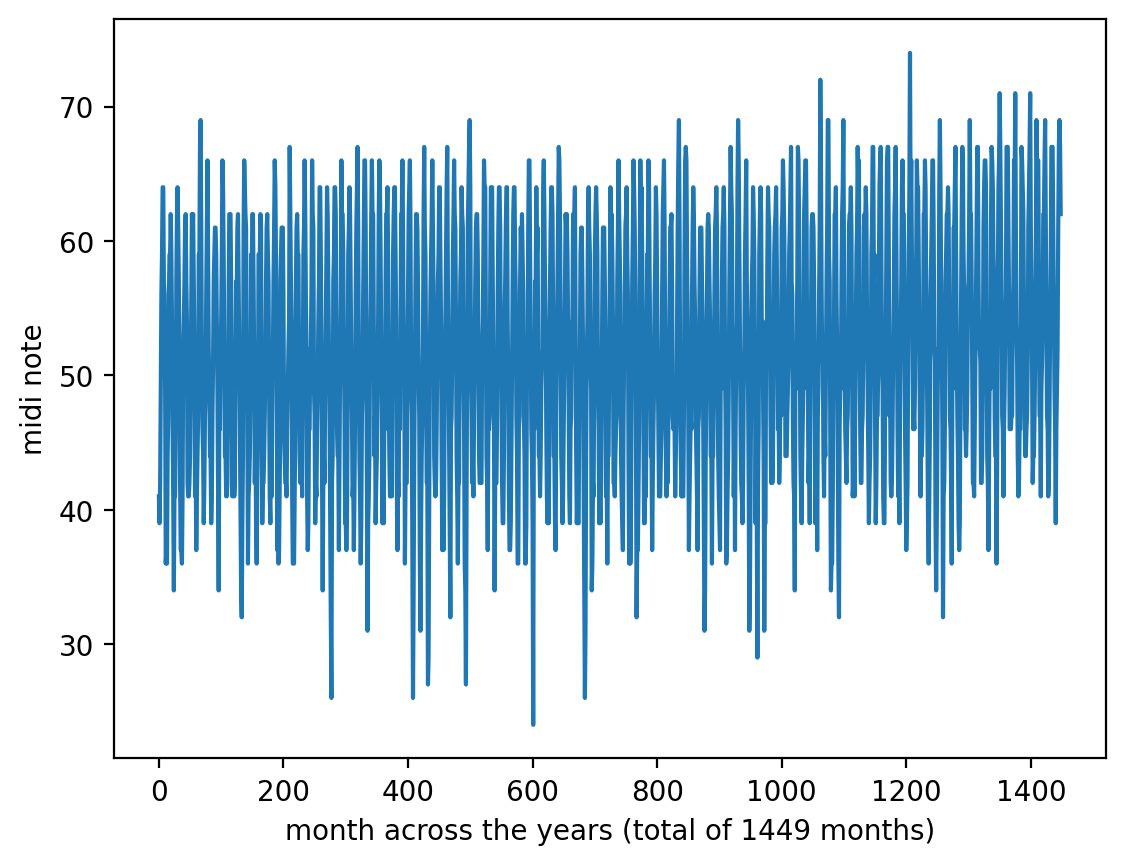

In [18]:
plt.plot(mapped_temps)
plt.xlabel('month across the years (total of 1449 months)')
plt.ylabel('midi note')

### comments regarding initial mapping 
- very repetitive and the note changes are maybe not super obvious. like it goes up and down but it's a little boring 
- maybe add an interactive element here as well? like a slider where you can adjust the pitch of the range of midi values that are played. for now the selected notes from the c lydian scale are hardcoded. maybe even add a slider to select a different scale (e.g. pentatonic??)